<a href="https://colab.research.google.com/github/Ndarila/ndarila.github.io/blob/master/Assignment_8_%E2%80%93_Classification_Models_James_Ndarila.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 8: Classification Models
**Cyber Shujaa Program (Data and AI Track)**  
**Student: James Ndarila Wanjala**
**Admission: cs-da01-25066**  
**Date: 3rd July 2025**  
---
In this assignment, we explore and compare six classification algorithms using the Wine dataset from Scikit-learn. Our goal is to train, evaluate, and compare model performance using standard evaluation metrics.


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


## Step 1: Load and Explore Dataset
We use the built-in Wine dataset from Scikit-learn, which contains chemical properties of wines classified into 3 types.


In [ ]:
# Load wine dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='target')

# View top records
X.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


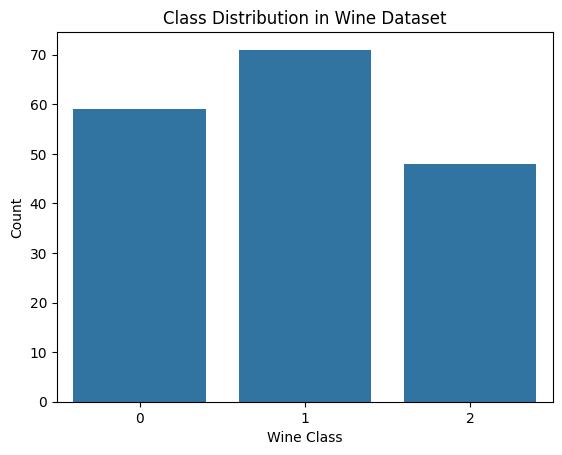

In [ ]:
# Class distribution
sns.countplot(x=y)
plt.title("Class Distribution in Wine Dataset")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.show()


## Step 2: Data Preprocessing
We standardize the feature values using `StandardScaler` and split the data into training and test sets (70/30 split).


In [ ]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# Show shapes of datasets
print("Training Features Shape:", X_train.shape)
print("Test Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Test Labels Shape:", y_test.shape)


Training Features Shape: (124, 13)
Test Features Shape: (54, 13)
Training Labels Shape: (124,)
Test Labels Shape: (54,)


## Step 3: Helper Function – Confusion Matrix Plot
The function below creates a heatmap of the confusion matrix for each classifier.


In [ ]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=wine.target_names,
                yticklabels=wine.target_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {title}")
    plt.show()


## Step 4: Train & Evaluate Models
We train six classification models and evaluate them using Accuracy, Classification Report, and Confusion Matrix.


In [ ]:
# Store results
results = pd.DataFrame(columns=["Model", "Accuracy"])


 Logistic Regression

Logistic Regression
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.95      0.98        21
           2       0.93      1.00      0.97        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



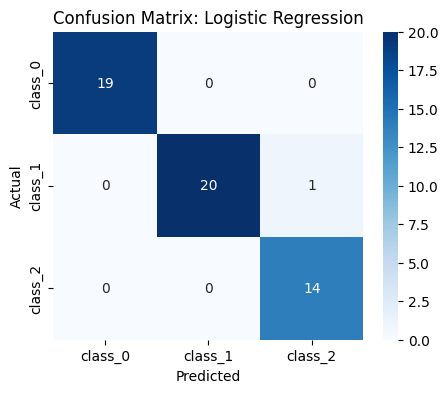

In [18]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression\n", classification_report(y_test, y_pred_lr))
plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression")
results.loc[len(results)] = ["Logistic Regression", accuracy_score(y_test, y_pred_lr)]


Decision Tree

Decision Tree
               precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54



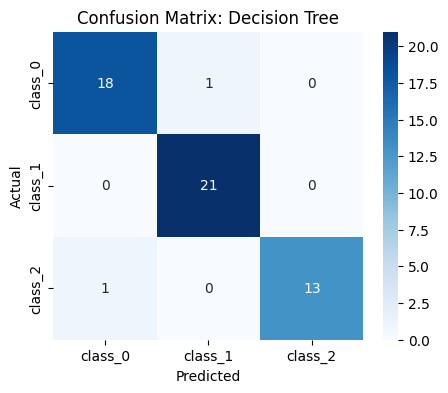

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree\n", classification_report(y_test, y_pred_dt))
plot_conf_matrix(y_test, y_pred_dt, "Decision Tree")
results.loc[len(results)] = ["Decision Tree", accuracy_score(y_test, y_pred_dt)]


Random Forest

Random Forest
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



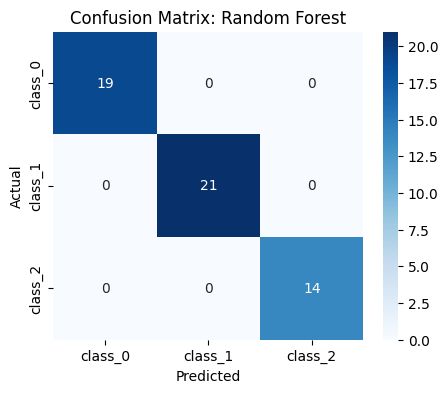

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest\n", classification_report(y_test, y_pred_rf))
plot_conf_matrix(y_test, y_pred_rf, "Random Forest")
results.loc[len(results)] = ["Random Forest", accuracy_score(y_test, y_pred_rf)]


K-Nearest Neighbors

KNN
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.90      0.95        21
           2       0.93      1.00      0.97        14

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



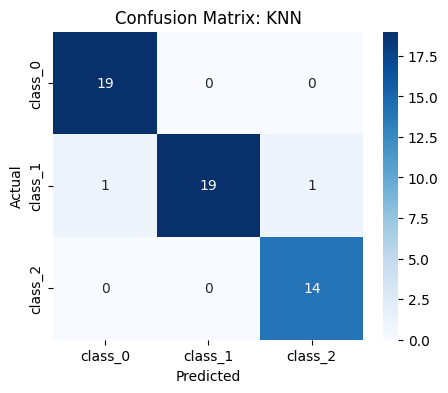

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN\n", classification_report(y_test, y_pred_knn))
plot_conf_matrix(y_test, y_pred_knn, "KNN")
results.loc[len(results)] = ["KNN", accuracy_score(y_test, y_pred_knn)]


Naive Bayes

Naive Bayes
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



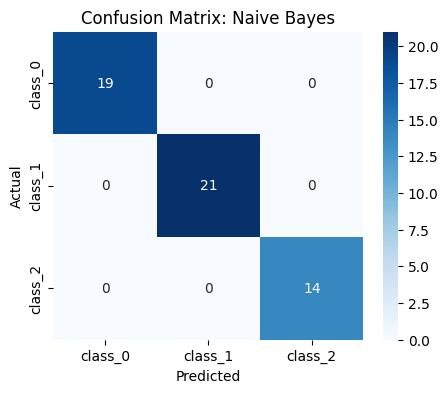

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes\n", classification_report(y_test, y_pred_nb))
plot_conf_matrix(y_test, y_pred_nb, "Naive Bayes")
results.loc[len(results)] = ["Naive Bayes", accuracy_score(y_test, y_pred_nb)]


SVM
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.96        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



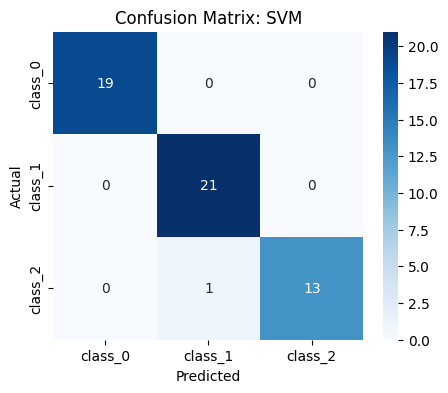

In [ ]:
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM\n", classification_report(y_test, y_pred_svm))
plot_conf_matrix(y_test, y_pred_svm, "SVM")
results.loc[len(results)] = ["SVM", accuracy_score(y_test, y_pred_svm)]


Support Vector Machine (SVM)

## Step 5: Model Comparison
We compare the accuracy scores of all models using a bar chart.


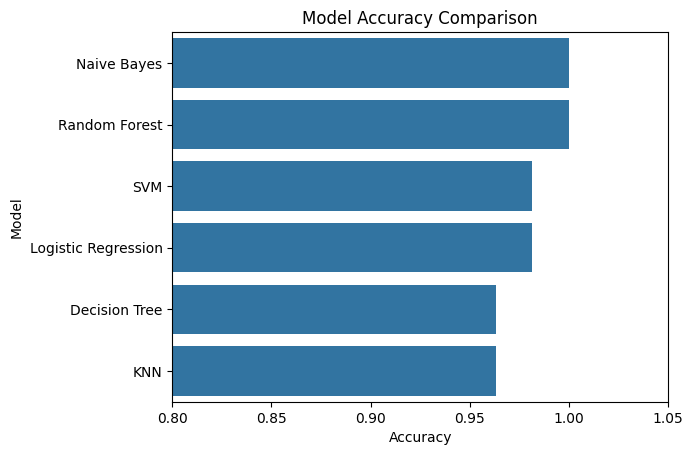

,Model,Accuracy
4,Naive Bayes,1.000000
2,Random Forest,1.000000
5,SVM,0.981481
0,Logistic Regression,0.981481
1,Decision Tree,0.962963
3,KNN,0.962963


In [ ]:
# Plot accuracy comparison
results.sort_values(by="Accuracy", ascending=False, inplace=True)
sns.barplot(x="Accuracy", y="Model", data=results)
plt.title("Model Accuracy Comparison")
plt.xlim(0.8, 1.05)
plt.show()

results


## Conclusion

All six classification models were successfully trained and evaluated on the Wine dataset.  
Among them, **Random Forest** and **Naive Bayes** both achieved the highest accuracy of **1.000**, making them the best performers in this task.

### Key Observations:
- **Random Forest**, **Naive Bayes**, and **Logistic Regression** performed exceptionally well.
- **Naive Bayes** achieved perfect accuracy despite its simplicity, likely due to the well-separated class distributions in this dataset.
- **Decision Tree** and **KNN** had slightly lower accuracy, possibly due to overfitting or sensitivity to feature scaling.
- **KNN**'s performance was solid but may vary with different values of `k`.

### Evaluation Metrics:
- **Accuracy** highlighted the top performers effectively.
- **Precision, Recall, and F1-score** helped assess the per-class performance.
- **Confusion matrices** visually confirmed model reliability.

---

### What I Learned:
- How to apply and evaluate multiple classification models in Python.
- The importance of **standardization** and **consistent model evaluation**.
- That performance varies by model depending on dataset characteristics and assumptions.

---

This assignment deepened my understanding of **supervised learning and model evaluation**, and gave me practical experience comparing multiple classifiers.
